#   PERCOBAAN 1
resize dan grayscale

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

In [2]:
data = []
labels = []
file_name = []

dataset_path = "." 

target_folders = ["Brokoli", "Kembang Kol"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    # Validasi: Pastikan itu adalah folder DAN termasuk dalam target_folders kita
    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

# Opsional: Cetak jumlah data untuk memastikan loading berhasil
print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 200
Distribusi label: (array(['Brokoli', 'Kembang Kol'], dtype='<U11'), array([100, 100]))


## Data Preparation

### Difine Preprocessing

In [3]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

### Preprocessing

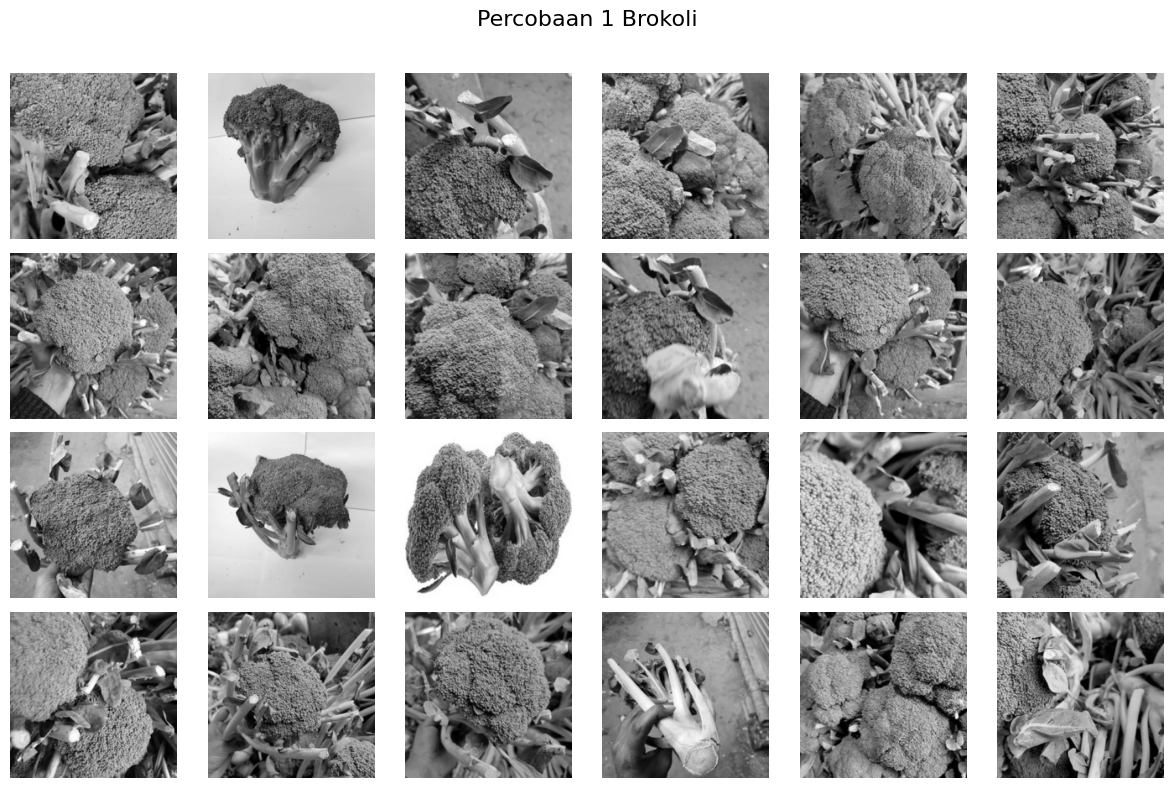

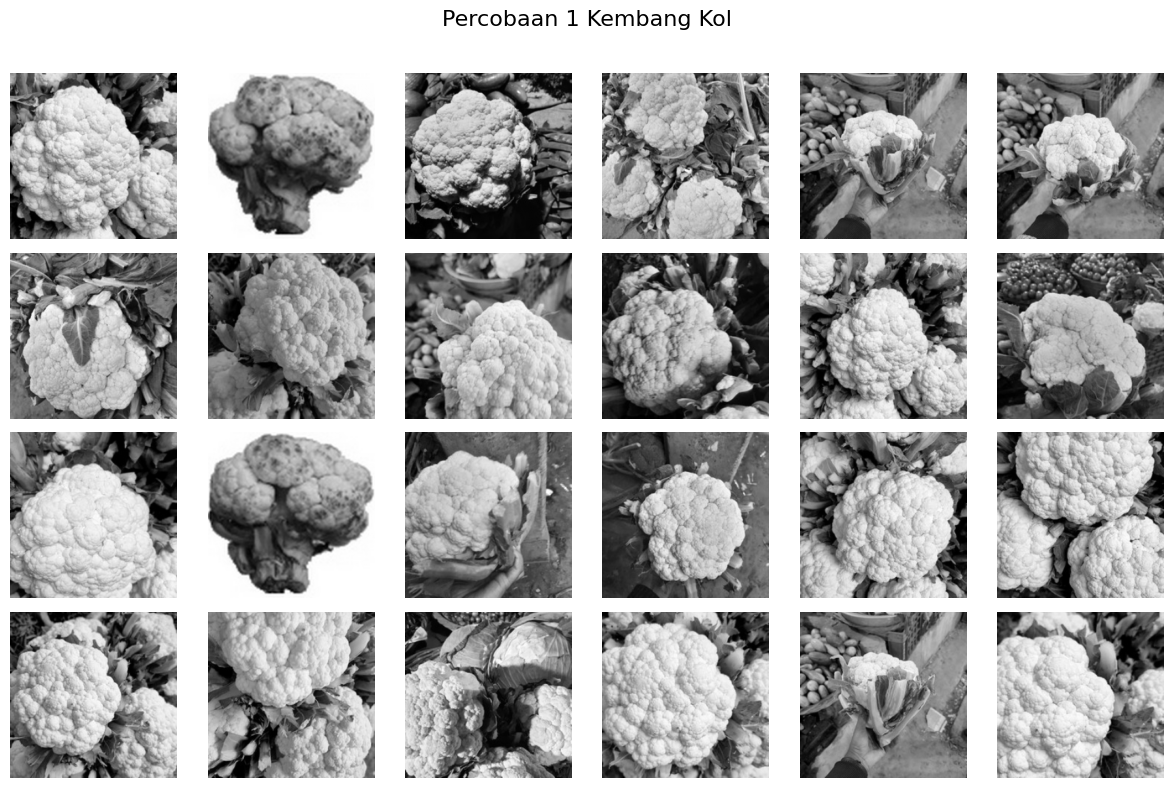

In [4]:
def percobaan1(img):
    img_gray = grayscale(img)
    img_resize = resize(img_gray, 256, 256)
    return img_resize

dataPreprocessed = [percobaan1(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 1 {label}', fontsize=16)
    
    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

### Ekstraksi Fitur

In [5]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [6]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [7]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,307.164905,0.909460,0.012661,0.119909,12.270695,0.000160,9.085177,percobaan1
1,76.113710,0.985818,0.079068,0.560881,3.990518,0.006252,6.840407,percobaan1
2,265.597610,0.935289,0.024664,0.234583,9.912255,0.000608,8.687929,percobaan1
3,212.167080,0.919365,0.014492,0.138478,10.159972,0.000210,8.860769,percobaan1
4,230.704366,0.940697,0.013526,0.125392,10.539507,0.000183,9.063417,percobaan1
...,...,...,...,...,...,...,...,...
195,115.472411,0.986319,0.013073,0.158912,7.634482,0.000171,9.000079,percobaan1
196,178.586121,0.981683,0.016135,0.173053,8.548376,0.000260,8.890101,percobaan1
197,153.772687,0.974027,0.014511,0.150262,8.360830,0.000211,8.875533,percobaan1
198,134.432353,0.982021,0.018013,0.180343,7.484069,0.000324,8.740163,percobaan1


In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Hasil Ekstraksi ke CSV

In [9]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [10]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,Brokoli,307.164905,595.903114,305.373575,430.195848,0.119909,0.091972,0.131496,0.098471,...,0.000167,0.000136,0.012661,0.011056,0.012907,0.011674,0.909460,0.824368,0.909959,0.873206
1,0002.jpg,Brokoli,76.113710,133.599385,67.737822,110.553649,0.560881,0.500176,0.553528,0.517303,...,0.005552,0.004832,0.079068,0.068090,0.074514,0.069511,0.985818,0.975168,0.987392,0.979452
2,0003.jpg,Brokoli,265.597610,377.807551,297.721293,572.312972,0.234583,0.203683,0.226346,0.176148,...,0.000588,0.000417,0.024664,0.022108,0.024248,0.020413,0.935289,0.907951,0.927500,0.860559
3,0004.jpg,Brokoli,212.167080,341.970150,274.790242,456.492703,0.138478,0.111266,0.128367,0.102747,...,0.000189,0.000151,0.014492,0.012912,0.013741,0.012292,0.919365,0.869837,0.895439,0.826251
4,0005.jpg,Brokoli,230.704366,342.334610,189.911305,384.428143,0.125392,0.106022,0.137071,0.100276,...,0.000195,0.000147,0.013526,0.012181,0.013965,0.012110,0.940697,0.911925,0.951278,0.901098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0096.jpg,Kembang Kol,115.472411,296.648043,202.387699,308.477739,0.158912,0.120256,0.148792,0.107566,...,0.000153,0.000114,0.013073,0.011096,0.012387,0.010658,0.986319,0.964844,0.976001,0.963441
196,0097.jpg,Kembang Kol,178.586121,277.499116,160.862316,335.756448,0.173053,0.149518,0.196512,0.138627,...,0.000295,0.000200,0.016135,0.014861,0.017182,0.014144,0.981683,0.971517,0.983520,0.965538
197,0098.jpg,Kembang Kol,153.772687,254.962061,143.596278,282.094225,0.150262,0.133312,0.167573,0.117981,...,0.000238,0.000159,0.014511,0.013664,0.015430,0.012606,0.974027,0.956869,0.975723,0.952279
198,0099.jpg,Kembang Kol,134.432353,228.855409,138.749724,257.831726,0.180343,0.145729,0.174417,0.132099,...,0.000314,0.000239,0.018013,0.015942,0.017722,0.015454,0.982021,0.969340,0.981414,0.965457


## Feature Selection

### ANOVA (Analysis of Variance)

Berdasarkan hasil pengujian menggunakan metode ANOVA (Analysis of Variance) untuk seleksi fitur, nilai F-Score yang diperoleh merepresentasikan tingkat sensitivitas atau kekuatan sebuah fitur piksel dalam membedakan karakteristik visual antara citra brokoli dan kembang kol. Ketika citra berukuran 256 x 256 piksel diratakan (flatten) menjadi sebuah larik satu dimensi berisi 65.536 fitur piksel, koordinat Piksel_32903 terbukti memiliki nilai F-Score tertinggi sebesar 66,93. Secara fisis, nilai yang tinggi ini menandakan adanya perbedaan kontras warna abu-abu (grayscale) yang sangat mencolok pada titik tersebut saat membandingkan kedua jenis sayuran. Kelompok piksel dengan indeks dominan di wilayah pertengahan, seperti deretan kepala 32.000-an dan 28.000-an, secara visual mengindikasikan area tekstur gumpalan utama atau pusat geometris dari bentuk sayuran. Pada area inilah letak perbedaan struktural paling krusial ditemukan, di mana brokoli cenderung memiliki karakteristik pori yang rapat dan gelap, sedangkan kembang kol menunjukkan pola lekukan yang jauh lebih terang.

Di sisi lain, evaluasi performa klasifikasi menggunakan algoritma Random Forest menunjukkan temuan yang sangat menarik terkait efisiensi pemangkasan dimensi data. Ketika model dilatih menggunakan keseluruhan informasi gambar dari ujung ke ujung tanpa seleksi fitur (65.536 piksel), tingkat akurasi yang dihasilkan mencapai 87,50%, yang berarti model mampu mengenali objek dengan sangat baik. Namun, saat dimensi data dipangkas secara ekstrem hingga sebesar 99,9% yaitu hanya menyisakan 50 piksel dengan skor ANOVA terbaik—model tetap mampu mempertahankan performa yang solid dengan raihan akurasi sebesar 80,00%. Penurunan akurasi yang tergolong minimal ini membuktikan secara empiris bahwa sebagian besar piksel pada citra asli bersifat redundan atau berupa noise (seperti area latar belakang). Melalui pemanfaatan seleksi fitur berbasis ANOVA, sistem berhasil mengisolasi titik-titik paling informatif sehingga proses komputasi menjadi jauh lebih ringan dan efisien tanpa harus mengorbankan kualitas prediksi secara signifikan.

In [11]:
X_images = np.array(dataPreprocessed)

# FLATTEN: Ubah gambar 2D (256x256) menjadi 1D (65536 fitur)
jumlah_sampel = X_images.shape[0]
X_asli = X_images.reshape(jumlah_sampel, -1) 

y_asli = np.array(labels)

nama_fitur = [f"Piksel_{i}" for i in range(X_asli.shape[1])]
X_train, X_test, y_train, y_test = train_test_split(X_asli, y_asli, test_size=0.2, random_state=42)

print(f"Data berhasil dimuat!")
print(f"Ukuran data training: {X_train.shape} (Artinya: {X_train.shape[0]} gambar, {X_train.shape[1]} nilai piksel)")

# ANOVA: Menghitung skor pengaruh setiap piksel dalam membedakan Brokoli vs Kembang Kol
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

df_pengaruh = pd.DataFrame({
    'Nama Piksel/Fitur': nama_fitur,
    'F-Score (Pengaruh)': selector.scores_
}).sort_values(by='F-Score (Pengaruh)', ascending=False)

print("\n--- URUTAN PIKSEL HASIL PREPROCESSING PALING BERPENGARUH ---")
print(df_pengaruh.head(10).to_string(index=False)) # Menampilkan 10 piksel terbaik
print("\n" + "="*50 + "\n")

# Skenario A: Menggunakan SEMUA Piksel Gambar (65.536 Fitur)
model_semua = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 agar lebih cepat
model_semua.fit(X_train, y_train)
acc_semua = accuracy_score(y_test, model_semua.predict(X_test))

# Skenario B: Hanya Menggunakan 50 Piksel Terbaik Hasil Seleksi ANOVA
K_TERBAIK = 50
selector_terbaik = SelectKBest(score_func=f_classif, k=K_TERBAIK)
X_train_selected = selector_terbaik.fit_transform(X_train, y_train)
X_test_selected = selector_terbaik.transform(X_test)

model_seleksi = RandomForestClassifier(random_state=42, n_jobs=-1)
model_seleksi.fit(X_train_selected, y_train)
acc_seleksi = accuracy_score(y_test, model_seleksi.predict(X_test_selected))

print("--- PERBANDINGAN AKURASI DATA ASLI ---")
print(f"Akurasi dengan SEMUA piksel ({X_asli.shape[1]} fitur) : {acc_semua * 100:.2f}%")
print(f"Akurasi dengan {K_TERBAIK} PIKSEL TERBAIK saja     : {acc_seleksi * 100:.2f}%")

Data berhasil dimuat!
Ukuran data training: (160, 65536) (Artinya: 160 gambar, 65536 nilai piksel)

--- URUTAN PIKSEL HASIL PREPROCESSING PALING BERPENGARUH ---
Nama Piksel/Fitur  F-Score (Pengaruh)
     Piksel_32903           66.938881
     Piksel_28008           66.843868
     Piksel_26514           66.730129
     Piksel_32906           65.992036
     Piksel_27284           65.966475
     Piksel_28264           65.927798
     Piksel_28560           64.072498
     Piksel_32907           63.803204
     Piksel_32904           63.654359
     Piksel_32905           63.402859


--- PERBANDINGAN AKURASI DATA ASLI ---
Akurasi dengan SEMUA piksel (65536 fitur) : 87.50%
Akurasi dengan 50 PIKSEL TERBAIK saja     : 80.00%


### Correlation

Berdasarkan hasil pengujian korelasi terhadap 28 fitur GLCM awal, ditemukan tingkat multikolinearitas yang sangat tinggi antar-fitur properti tekstur. Dengan menerapkan threshold korelasi sebesar 0.85, sistem berhasil mereduksi dimensi data secara signifikan hingga menyisakan 3 fitur independen terbaik, yaitu Contrast0, Homogeneity0, dan ASM0. Meskipun eliminasi data redundan ini menyebabkan penurunan akurasi model Random Forest dari 92.50% menjadi 82.50%, penggunaan 3 fitur hasil seleksi ini dinilai jauh lebih efisien dalam memangkas waktu komputasi training model secara masif dengan tetap mempertahankan performa klasifikasi objek brokoli dan kembang kol yang kuat.

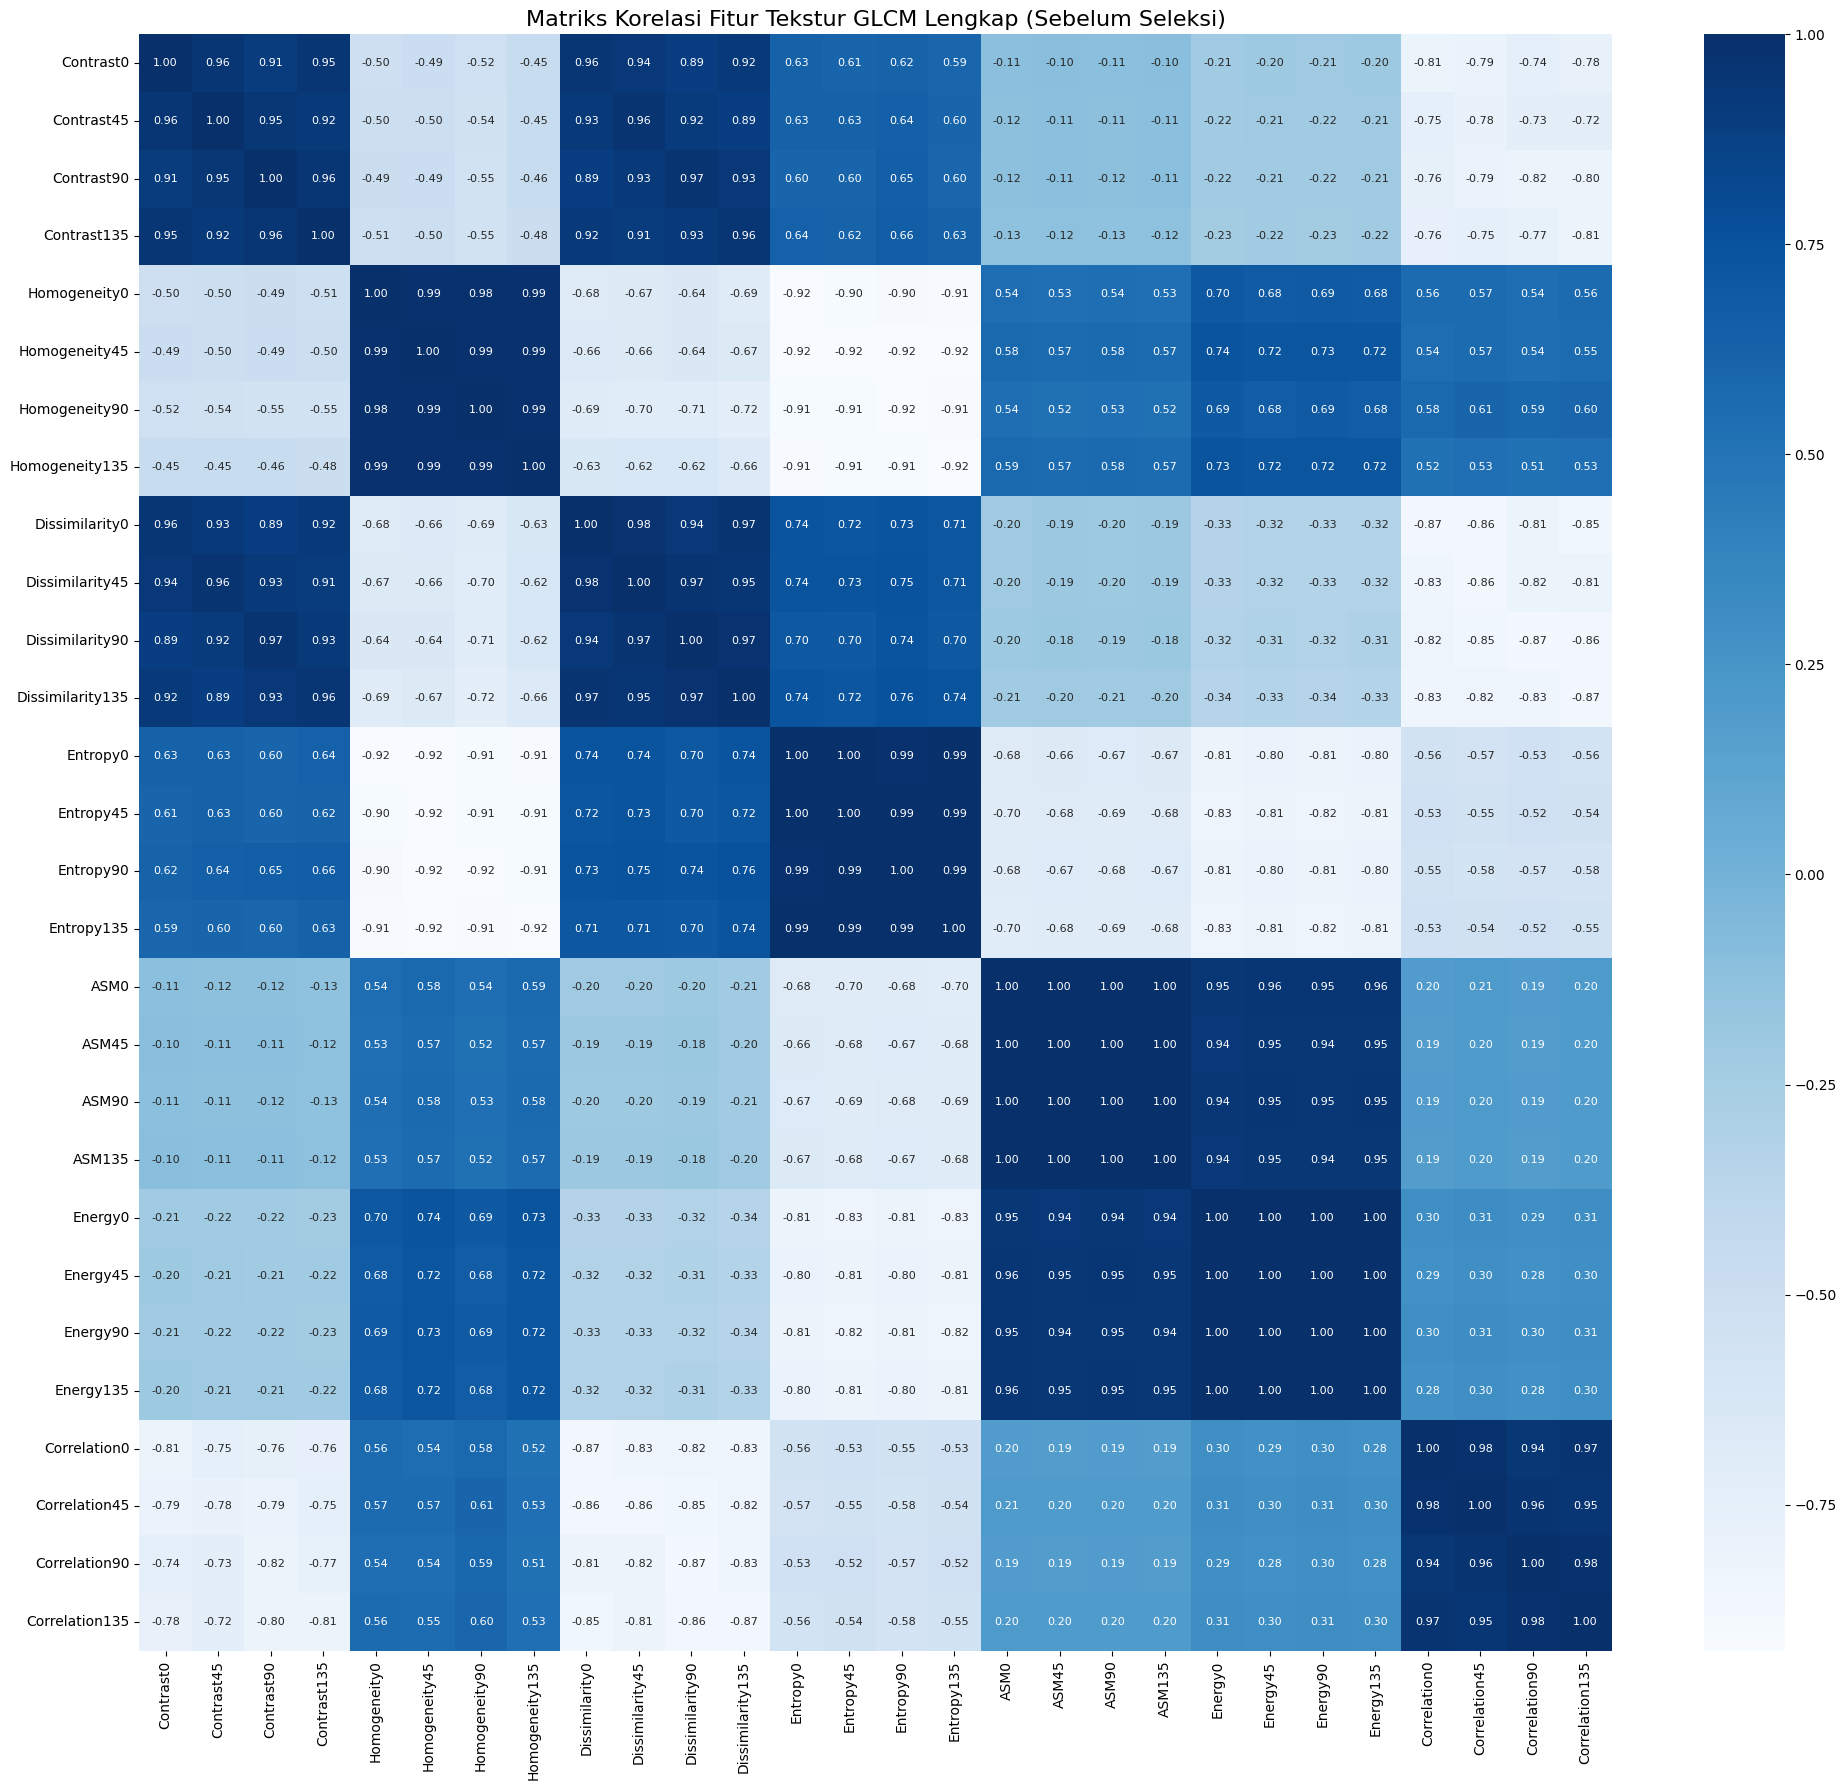

--- HASIL SELEKSI FITUR ---
Jumlah fitur awal : 28 fitur
Jumlah fitur setelah disaring (Korelasi < 0.85) : 3 fitur
Fitur yang terpilih: ['Contrast0', 'Homogeneity0', 'ASM0']

Akurasi SEBELUM Seleksi Korelasi (28 fitur): 92.50%
Akurasi SETELAH Seleksi Korelasi (3 fitur) : 82.50%


In [12]:
correlation = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f", cbar=True, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Tekstur GLCM Lengkap (Sebelum Seleksi)", fontsize=16)
plt.tight_layout()
plt.show()

threshold = 0.85 
columns_mask = np.full((correlation.shape[0],), True, dtype=bool)

for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if abs(correlation.iloc[i, j]) >= threshold:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]

x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"--- HASIL SELEKSI FITUR ---")
print(f"Jumlah fitur awal : {correlation.shape[0]} fitur")
print(f"Jumlah fitur setelah disaring (Korelasi < {threshold}) : {x_new.shape[1]} fitur")
print(f"Fitur yang terpilih: {list(select)}\n")

# Split data menggunakan fitur awal vs fitur baru
X_train_old, X_test_old, y_train, y_test = train_test_split(
    hasilEkstrak.drop(columns=['Label', 'Filename']), y, test_size=0.2, random_state=42
)
X_train_new, X_test_new, _, _ = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Model dengan fitur awal
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# Model dengan fitur hasil seleksi
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print("="*60)
print(f"Akurasi SEBELUM Seleksi Korelasi ({correlation.shape[0]} fitur): {acc_old * 100:.2f}%")
print(f"Akurasi SETELAH Seleksi Korelasi ({x_new.shape[1]} fitur) : {acc_new * 100:.2f}%")
print("="*60)

### Spliting Data

In [13]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


### Feature Normalization

In [14]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Kode ini digunakan untuk normalisasi mean-std (Standardisasi atau Z-score normalization) pada fitur-fitur training (X_train) dan testing set (X_test). Normalisasi ini dilakukan dengan mengurangi setiap nilai fitur dengan rata-rata training set (X_train.mean()) dan membaginya dengan standar deviasi training set (X_train.std()). Pentingnya metode ini adalah bahwa rata-rata dan standar deviasi hanya dihitung dari X_train dan kemudian diterapkan ke X_test, sebuah praktik yang mencegah data leakage dan memastikan integritas pengujian model.

## Modeling

### Define Model

In [15]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [16]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.98      1.00      0.99        79
 Kembang Kol       1.00      0.98      0.99        81

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160

[[79  0]
 [ 2 79]]
Accuracy: 0.9875

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.89      0.81      0.85        21
 Kembang Kol       0.81      0.89      0.85        19

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40

[[17  4]
 [ 2 17]]
Accuracy: 0.85


### Train SVM Classifier

In [17]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.88      0.91      0.89        79
 Kembang Kol       0.91      0.88      0.89        81

    accuracy                           0.89       160
   macro avg       0.89      0.89      0.89       160
weighted avg       0.89      0.89      0.89       160

[[72  7]
 [10 71]]
Accuracy: 0.89375

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.84      0.76      0.80        21
 Kembang Kol       0.76      0.84      0.80        19

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40

[[16  5]
 [ 3 16]]
Accuracy: 0.8


### Train KNN Classifier

In [18]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.92      0.92      0.92        79
 Kembang Kol       0.93      0.93      0.93        81

    accuracy                           0.93       160
   macro avg       0.92      0.92      0.92       160
weighted avg       0.93      0.93      0.93       160

[[73  6]
 [ 6 75]]
Accuracy: 0.925

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.89      0.81      0.85        21
 Kembang Kol       0.81      0.89      0.85        19

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40

[[17  4]
 [ 2 17]]
Accuracy: 0.85


### Evaluasi Dengan Confussion Matrix

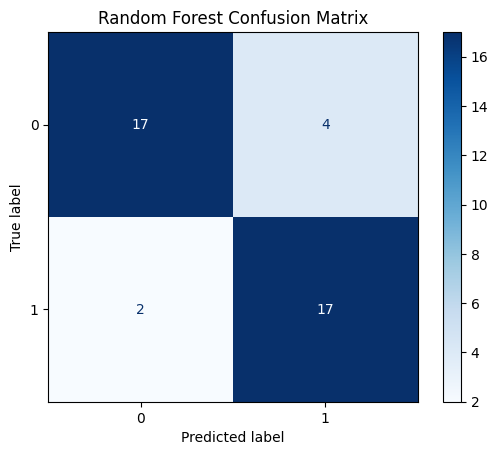

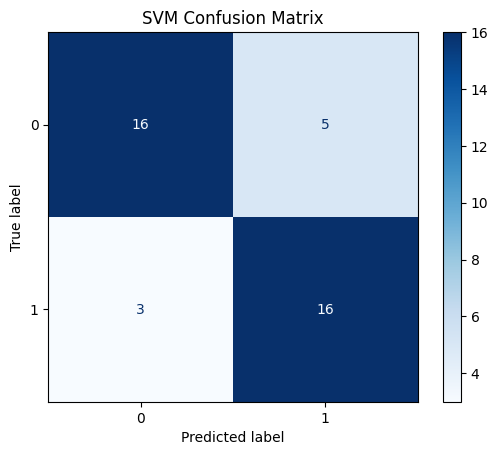

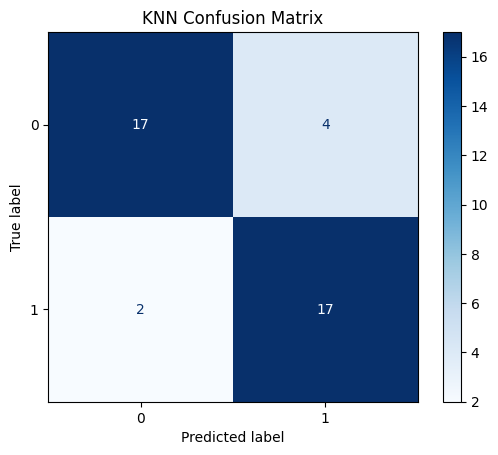

In [19]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")